In [5]:
import os
import glob
import geopandas as gpd

In [6]:
# ================== User Settings ==================
ROOT_FOLDER = r"Grid_Zonal_Stats"   # root folder containing the variable subfolders
VARIABLES = ["BuildingFootprint", "ImperviousSurface", "TreeCanopy"]

JOIN_FIELD = "GRID_ID"
STAT_COLUMN = "_mean"   # column to pull from each shapefile

OUTPUT_DIR = os.path.join(ROOT_FOLDER, "Grid_Zonal_Stats")
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_GPKG = os.path.join(OUTPUT_DIR, "01_Variable_Statistics.gpkg")

In [12]:
def load_variable_mean(root_folder, variable, join_field=JOIN_FIELD, stat_col=STAT_COLUMN):
    """
    Loads the shapefile for a variable and returns a GeoDataFrame with
    just [join_field, geometry, f"{variable}_mean"].
    """
    var_folder = os.path.join(root_folder, variable)
    shp_files = sorted(glob.glob(os.path.join(var_folder, "*.shp")))

    if not shp_files:
        raise FileNotFoundError(f"No .shp files found in {var_folder}")

    gdf = gpd.read_file(shp_files[0])

    if gdf.crs is None:
        print(f"  Warning: {shp_files[0]} has no CRS defined (missing/unreadable .prj file)")
    else:
        print(f"  {variable} CRS: {gdf.crs}")

    if join_field not in gdf.columns:
        raise KeyError(f"{join_field} not found in {shp_files[0]}. Columns: {list(gdf.columns)}")
    if stat_col not in gdf.columns:
        raise KeyError(f"{stat_col} not found in {shp_files[0]}. Columns: {list(gdf.columns)}")

    renamed_col = f"{variable}_mean"
    out = gdf[[join_field, stat_col, "geometry"]].rename(columns={stat_col: renamed_col})

    print(f"Loaded {variable}: {len(out)} rows -> column '{renamed_col}'")
    return out

In [15]:
def merge_variable_stats(root_folder, variables, join_field=JOIN_FIELD, stat_col=STAT_COLUMN):
    """
    Loads each variable's mean stat and merges them all on join_field.
    Geometry and CRS are kept from the first variable loaded.
    """
    merged = None
    reference_crs = None

    for i, var in enumerate(variables):
        gdf = load_variable_mean(root_folder, var, join_field, stat_col)

        if merged is None:
            merged = gdf
            reference_crs = gdf.crs
        else:
            if gdf.crs != reference_crs:
                print(f"  Warning: {var} CRS ({gdf.crs}) differs from reference ({reference_crs}); "
                      f"reprojecting geometry-less columns only, no reprojection needed since "
                      f"geometry is dropped here.")
            gdf_no_geom = gdf.drop(columns="geometry")
            merged = merged.merge(gdf_no_geom, on=join_field, how="outer")

    # re-assert as a GeoDataFrame with the correct CRS/geometry column,
    # since a merge can sometimes silently lose CRS metadata
    merged = gpd.GeoDataFrame(merged, geometry="geometry", crs=reference_crs)

    if reference_crs is None:
        print("\nWarning: no CRS could be determined from any input shapefile. "
              "The output gpkg will be saved without projection info. "
              "Check that each .shp has a matching .prj file.")

    n_mismatched = merged[[f"{v}_mean" for v in variables]].isna().any(axis=1).sum()
    if n_mismatched > 0:
        print(f"\nWarning: {n_mismatched} grid cell(s) are missing a value from at least one variable "
              f"(GRID_ID didn't match across all three files).")

    return merged

In [16]:
merged_gdf = merge_variable_stats(ROOT_FOLDER, VARIABLES, join_field=JOIN_FIELD, stat_col=STAT_COLUMN)

print(f"\nFinal merged table: {len(merged_gdf)} rows, columns: {list(merged_gdf.columns)}")

merged_gdf.to_file(OUTPUT_GPKG, driver="GPKG")
print(f"\nSaved -> {OUTPUT_GPKG}")

Loaded BuildingFootprint: 39940 rows -> column 'BuildingFootprint_mean'
Loaded ImperviousSurface: 39940 rows -> column 'ImperviousSurface_mean'
Loaded TreeCanopy: 39940 rows -> column 'TreeCanopy_mean'



Final merged table: 39940 rows, columns: ['GRID_ID', 'BuildingFootprint_mean', 'geometry', 'ImperviousSurface_mean', 'TreeCanopy_mean']


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(



Saved -> Grid_Zonal_Stats/Grid_Zonal_Stats/01_Variable_Statistics.gpkg


In [17]:
merged_gdf

,GRID_ID,BuildingFootprint_mean,geometry,ImperviousSurface_mean,TreeCanopy_mean
0,AAA-1000,0.0,"POLYGON ((328523.871 -548012.65, 328523.871 -5...",0.145045,3.935135
1,AAA-1001,0.0,"POLYGON ((328523.871 -549012.65, 328523.871 -5...",0.000000,8.623201
2,AAA-1002,0.0,"POLYGON ((328523.871 -550012.649, 328523.871 -...",0.000000,3.965797
3,AAA-1003,0.0,"POLYGON ((328523.871 -551012.65, 328523.871 -5...",0.000000,3.860486
4,AAA-1004,0.0,"POLYGON ((328523.871 -552012.649, 328523.871 -...",0.000000,8.619262
...,...,...,...,...,...
39935,ZZ-995,0.0,"POLYGON ((327523.871 -543012.649, 327523.871 -...",0.000000,6.179118
39936,ZZ-996,0.0,"POLYGON ((327523.871 -544012.65, 327523.871 -5...",0.000000,9.075540
39937,ZZ-997,0.0,"POLYGON ((327523.871 -545012.649, 327523.871 -...",0.000000,6.729317
39938,ZZ-998,0.0,"POLYGON ((327523.871 -546012.65, 327523.871 -5...",0.000000,4.304230


Merge

In [20]:
# ================== Merge with Final Phase Averages ==================
FINAL_PHASE_AVERAGES_GPKG = r"/Users/ks/Desktop/Wu/Summer26/04_Final_Phase_Averages/Final_Phase_Averages.gpkg"
PHASE_GRID_ID_FIELD = "GRID_ID"   # the ID field used in Final_Phase_Averages.gpkg

FINAL_COMBINED_GPKG = os.path.join(OUTPUT_DIR, "02_Variable_and_Phase_Statistics.gpkg")

phase_gdf = gpd.read_file(FINAL_PHASE_AVERAGES_GPKG)
print(f"Loaded Final_Phase_Averages: {len(phase_gdf)} rows, columns: {list(phase_gdf.columns)}")

if PHASE_GRID_ID_FIELD not in phase_gdf.columns:
    raise KeyError(f"{PHASE_GRID_ID_FIELD} not found in {FINAL_PHASE_AVERAGES_GPKG}. "
                    f"Columns: {list(phase_gdf.columns)}")

# coerce both join keys to string so an int vs. object dtype mismatch
# doesn't silently cause every row to fail to match
merged_gdf[JOIN_FIELD] = merged_gdf[JOIN_FIELD].astype(str)
phase_gdf[PHASE_GRID_ID_FIELD] = phase_gdf[PHASE_GRID_ID_FIELD].astype(str)

# drop geometry from the variable stats side (keep geometry from phase_gdf)
# since phase_gdf is the ECOSTRESS grid this analysis is ultimately keyed to
merged_no_geom = merged_gdf.drop(columns="geometry")

combined_gdf = phase_gdf.merge(
    merged_no_geom,
    left_on=PHASE_GRID_ID_FIELD,
    right_on=JOIN_FIELD,
    how="left",
)

n_unmatched = combined_gdf[[f"{v}_mean" for v in VARIABLES]].isna().all(axis=1).sum()
if n_unmatched > 0:
    print(f"\nWarning: {n_unmatched} grid cell(s) in Final_Phase_Averages had no matching "
          f"{JOIN_FIELD} in the variable statistics (check that {PHASE_GRID_ID_FIELD} and "
          f"{JOIN_FIELD} actually reference the same grid).")

combined_gdf = gpd.GeoDataFrame(combined_gdf, geometry="geometry", crs=phase_gdf.crs)

combined_gdf.to_file(FINAL_COMBINED_GPKG, driver="GPKG")
print(f"\nSaved -> {FINAL_COMBINED_GPKG}")

# ================== Descriptive Stats ==================
numeric_cols = combined_gdf.select_dtypes(include="number").columns.tolist()
print(f"\nDescriptive statistics for numeric columns:")
print(combined_gdf[numeric_cols].describe())

combined_gdf

Loaded Final_Phase_Averages: 4255 rows, columns: ['GRID_ID', 'Night', 'Morning', 'Evening', 'geometry']

Saved -> Grid_Zonal_Stats/Grid_Zonal_Stats/02_Variable_and_Phase_Statistics.gpkg

Descriptive statistics for numeric columns:
             Night      Morning      Evening  BuildingFootprint_mean  \
count  4255.000000  4255.000000  4255.000000             4255.000000   
mean    292.673676   298.055756   303.051392                0.320076   
std       2.044317     2.989654     2.546523                0.606482   
min     287.659119   290.530518   296.618530                0.000000   
25%     291.082550   295.723083   301.039825                0.000000   
50%     292.557800   297.922089   303.163666                0.015274   
75%     294.240402   300.385605   305.222870                0.234234   
max     298.893280   307.880280   309.486755                2.998201   

       ImperviousSurface_mean  TreeCanopy_mean  
count             4255.000000      4255.000000  
mean                12

,GRID_ID,Night,Morning,Evening,geometry,BuildingFootprint_mean,ImperviousSurface_mean,TreeCanopy_mean
0,HG-454,296.046692,298.391235,303.108826,"POLYGON ((-159476.129 -2012.649, -159476.129 -...",0.653153,29.937050,4.586331
1,HH-454,295.859863,298.623993,303.325287,"POLYGON ((-158476.129 -2012.649, -158476.129 -...",1.005401,34.184685,4.997297
2,HI-454,296.381531,297.759338,304.967285,"POLYGON ((-157476.129 -2012.649, -157476.129 -...",1.377138,51.580558,5.451845
3,HJ-454,296.214020,297.491150,304.683533,"POLYGON ((-156476.129 -2012.649, -156476.129 -...",1.650450,47.538254,6.903690
4,HK-454,296.118042,297.068207,304.788879,"POLYGON ((-155476.129 -2012.649, -155476.129 -...",1.497297,43.451439,5.542266
...,...,...,...,...,...,...,...,...
4250,IG-365,295.114197,298.447906,303.581543,"POLYGON ((-133476.129 86987.351, -133476.129 8...",0.000000,2.408273,0.000000
4251,IH-365,294.852844,296.029388,301.044281,"POLYGON ((-132476.129 86987.351, -132476.129 8...",0.000000,0.000000,0.000000
4252,II-365,292.713440,296.570129,302.782990,"POLYGON ((-131476.129 86987.351, -131476.129 8...",0.004505,0.106211,0.000000
4253,IJ-365,293.349884,296.730743,302.755249,"POLYGON ((-130476.129 86987.351, -130476.129 8...",0.015302,0.485149,0.000000


In [25]:
PHASE_CATEGORIES = ["Night", "Morning", "Afternoon", "Evening"]

# only keep phase columns that actually exist in combined_gdf
existing_phase_cols = [c for c in PHASE_CATEGORIES if c in combined_gdf.columns]

if not existing_phase_cols:
    raise KeyError(f"None of {PHASE_CATEGORIES} found in combined_gdf. "
                    f"Columns: {list(combined_gdf.columns)}")

has_lst = combined_gdf[existing_phase_cols].notna().any(axis=1)

n_before = len(combined_gdf)
combined_gdf_filtered = combined_gdf[has_lst].reset_index(drop=True)
n_after = len(combined_gdf_filtered)

print(f"Removed {n_before - n_after} grid cell(s) with no LST values in any phase "
      f"({existing_phase_cols}).")
print(f"Remaining: {n_after} grid cells")

combined_gdf_filtered = gpd.GeoDataFrame(combined_gdf, geometry="geometry", crs=phase_gdf.crs)

combined_gdf_filtered.to_file(FINAL_COMBINED_GPKG, driver="GPKG")
print(f"\nSaved -> {FINAL_COMBINED_GPKG}")


Removed 0 grid cell(s) with no LST values in any phase (['Night', 'Morning', 'Evening']).
Remaining: 4255 grid cells

Saved -> Grid_Zonal_Stats/Grid_Zonal_Stats/02_Variable_and_Phase_Statistics.gpkg


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_25418/2598318836.py:15: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_25418/2598318836.py:15: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_25418/2598318836.py:15: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)


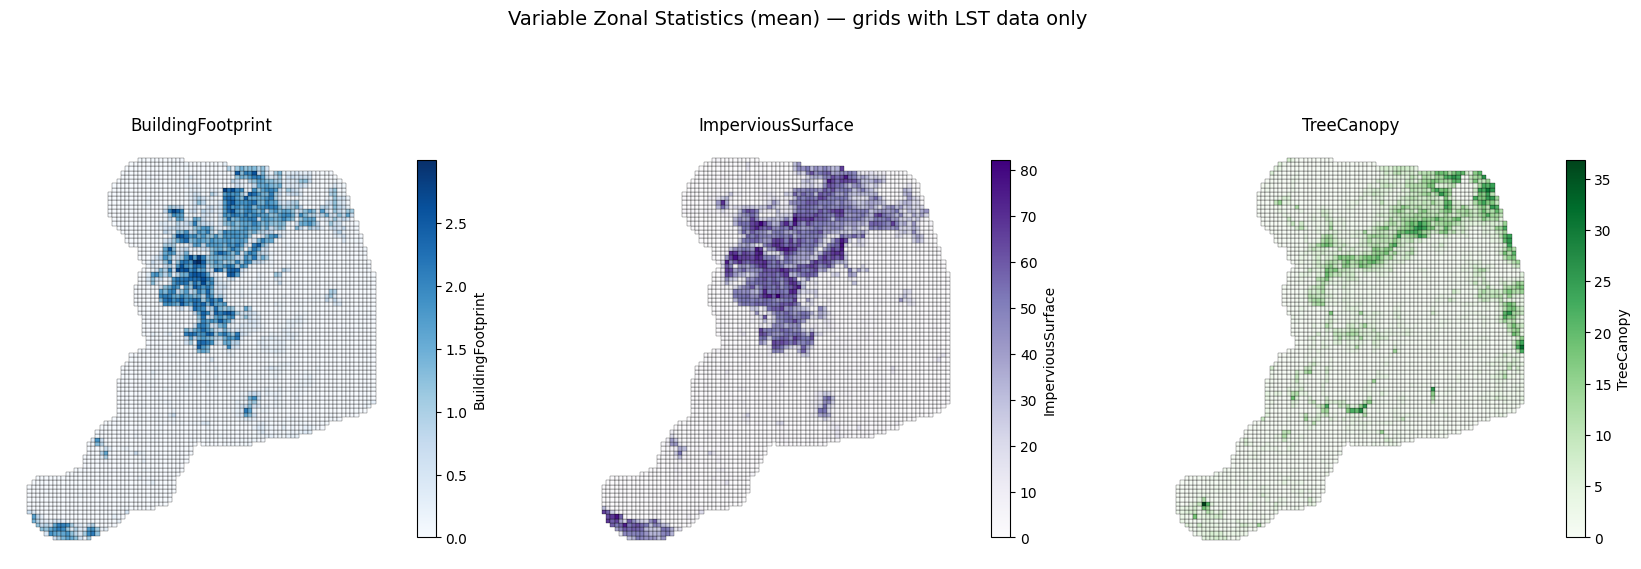

Saved -> Grid_Zonal_Stats/Grid_Zonal_Stats/Variable_Statistics_Row_Colored.png


In [24]:
def plot_variable_stats_row_colored(gdf, variables, cmaps, out_dir):
    """
    Plots each variable's mean statistic in a single row, one panel per
    variable, using a distinct single-hue colormap per variable
    (white for no data).
    """
    fig, axes = plt.subplots(1, len(variables), figsize=(7 * len(variables), 7))
    if len(variables) == 1:
        axes = [axes]

    for ax, var, cmap in zip(axes, variables, cmaps):
        col = f"{var}_mean"
        has_data = gdf[col].notna()

        gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
        gdf[has_data].plot(
            ax=ax,
            column=col,
            cmap=cmap,
            edgecolor="black",
            linewidth=0.2,
            legend=True,
            legend_kwds={"shrink": 0.7, "label": var},
        )

        ax.set_title(var)
        ax.axis("off")

    fig.suptitle("Variable Zonal Statistics (mean) — grids with LST data only", fontsize=14)

    out_path = os.path.join(out_dir, "Variable_Statistics_Row_Colored.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    return out_path


VARIABLE_CMAPS = {
    "BuildingFootprint": "Blues",
    "ImperviousSurface": "Purples",
    "TreeCanopy": "Greens",
}

cmap_list = [VARIABLE_CMAPS[v] for v in VARIABLES]

png_path = plot_variable_stats_row_colored(combined_gdf_filtered, VARIABLES, cmap_list, OUTPUT_DIR)
print(f"Saved -> {png_path}")